# Copula Analysis: Tail Dependence Between CDS and DD

Design:
- Variables: CDS and −DD in **levels**
- Pseudo-uniforms computed **within each country** (removing cross-country level differences)
- Pooled within group (Exporter / Control) after within-country ranking
- Fit Gumbel, Clayton, Frank by MLE per group × model (6 fits)
- Primary result: upper tail dependence λ_U from Gumbel
- Expected: M0 exporters ≈ M0 controls; M1/M2 exporters > M1/M2 controls

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman']
matplotlib.rcParams['font.size'] = 8

In [28]:
# ── Paths ──────────────────────────────────────────────────────────────────
GAMMA = 15  # change to 5 or 25 for robustness
RESULTS_PATH = f'../output/Current_results/complete_results_weekly_{GAMMA}_dampening.csv'

DATE_COL    = 'date'
COUNTRY_COL = 'country'
CDS_COL     = 'cds_spread'
DD_COLS     = {'M0': 'DD_M0', 'M1': 'DD_M1', 'M2': 'DD_M2'}

In [29]:
EXPORTERS = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Colombia', 'Mexico',
             'Brazil', 'Egypt', 'Malaysia', 'Qatar']
CONTROLS  = ['Chile', 'China', 'Indonesia', 'Philippines',
             'South Africa', 'South Korea', 'Thailand', 'Turkey']

In [30]:
df = pd.read_csv(RESULTS_PATH, parse_dates=[DATE_COL])
df = df.sort_values([COUNTRY_COL, DATE_COL]).reset_index(drop=True)
print(df.shape)
print(df.columns.tolist())
df.head(3)

(8352, 26)
['date', 'country', 'cds_spread', 'risk_free_rate', 'B_f', 'LCL_usd', 'sigma_lcl', 'implied_V_M0', 'implied_sigma_V_M0', 'cca_converged_M0', 'implied_V_M1', 'implied_sigma_V_M1', 'cca_converged_M1', 'convenience_yield', 'implied_V_M2', 'implied_sigma_V_M2', 'cca_converged_M2', 'lambda_annual', 'group', 'exporter', 'DD_M0', 'DD_M1', 'DD_M2', 'PD_M0', 'PD_M1', 'PD_M2']


,date,country,cds_spread,risk_free_rate,B_f,LCL_usd,sigma_lcl,implied_V_M0,implied_sigma_V_M0,cca_converged_M0,...,cca_converged_M2,lambda_annual,group,exporter,DD_M0,DD_M1,DD_M2,PD_M0,PD_M1,PD_M2
0,2015-01-04,Brazil,207.97,0.0255,631.8961,792.778598,0.156749,1349.032253,0.092116,True,...,True,8.155143,Exporter,1.0,4.198043,3.634887,3.178353,0.000013,0.000139,0.000741
1,2015-01-11,Brazil,201.92,0.0255,631.8961,812.065172,0.158278,1368.318794,0.093935,True,...,True,7.705558,Exporter,1.0,4.180310,3.529999,3.223647,0.000015,0.000208,0.000633
2,2015-01-18,Brazil,205.65,0.0255,631.8961,814.905830,0.158203,1371.159461,0.094024,True,...,True,8.384939,Exporter,1.0,4.186038,3.612942,3.167098,0.000014,0.000151,0.000770


In [31]:
# ── Within-country pseudo-uniforms ──────────────────────────────────────────
# Rank CDS and -DD within each country's own history, then pool across countries.
# This removes cross-country level differences while preserving within-country
# dependence structure.

def within_country_uniforms(group_countries, model):
    u_all, v_all = [], []
    dd_col = DD_COLS[model]
    for country in group_countries:
        mask = df[COUNTRY_COL] == country
        sub  = df.loc[mask, [CDS_COL, dd_col]].dropna()
        if len(sub) < 10:
            continue
        n = len(sub)
        u = rankdata(sub[CDS_COL].values)  / (n + 1)  # high CDS  = high u
        v = rankdata(-sub[dd_col].values)  / (n + 1)  # low DD    = high v
        u_all.append(u)
        v_all.append(v)
    return np.concatenate(u_all), np.concatenate(v_all)

In [32]:
# ── Sanity check ────────────────────────────────────────────────────────────
for group_name, countries in [('Exporter', EXPORTERS), ('Control', CONTROLS)]:
    u, v = within_country_uniforms(countries, 'M0')
    print(f'{group_name} M0 — N={len(u)}, corr(u,v)={np.corrcoef(u,v)[0,1]:.4f}')

Exporter M0 — N=4176, corr(u,v)=0.4651
Control M0 — N=4176, corr(u,v)=0.0998


In [33]:
# ── Copula log-likelihoods ──────────────────────────────────────────────────

def gumbel_loglik(u, v, theta):
    if theta < 1 + 1e-6:
        return -np.inf
    lu = -np.log(np.clip(u, 1e-10, 1-1e-10))
    lv = -np.log(np.clip(v, 1e-10, 1-1e-10))
    A  = lu**theta + lv**theta
    log_C = -A**(1/theta)
    log_c = (log_C
             + (1/theta - 2) * np.log(A)
             + (theta - 1) * (np.log(lu) + np.log(lv))
             - np.log(u) - np.log(v)
             + np.log(A**(-1/theta) + theta - 1))
    return np.sum(log_c)

def clayton_loglik(u, v, theta):
    if theta < 1e-6:
        return -np.inf
    u = np.clip(u, 1e-10, 1-1e-10)
    v = np.clip(v, 1e-10, 1-1e-10)
    log_c = (np.log(1 + theta)
             - (1 + theta) * np.log(u)
             - (1 + theta) * np.log(v)
             + (-(2 + 1/theta)) * np.log(u**(-theta) + v**(-theta) - 1))
    return np.sum(log_c)

def frank_loglik(u, v, theta):
    if abs(theta) < 1e-6:
        return -np.inf
    u = np.clip(u, 1e-10, 1-1e-10)
    v = np.clip(v, 1e-10, 1-1e-10)
    et  = np.exp(-theta)
    etu = np.exp(-theta * u)
    etv = np.exp(-theta * v)
    num = theta * (et - 1) * np.exp(-theta * (u + v))
    den = ((et - 1) + (etu - 1) * (etv - 1))**2
    log_c = np.log(np.clip(num / den, 1e-300, None))
    return np.sum(log_c)

In [34]:
# ── Fitting ─────────────────────────────────────────────────────────────────

def fit_gumbel(u, v):
    res   = minimize_scalar(lambda th: -gumbel_loglik(u, v, th),
                            bounds=(1.001, 20), method='bounded')
    theta = res.x
    ll    = -res.fun
    aic   = -2*ll + 2
    tail  = 2 - 2**(1/theta)
    return dict(family='Gumbel', theta=theta, loglik=ll, AIC=aic, tail_dep=tail)

def fit_clayton(u, v):
    res   = minimize_scalar(lambda th: -clayton_loglik(u, v, th),
                            bounds=(0.001, 30), method='bounded')
    theta = res.x
    ll    = -res.fun
    aic   = -2*ll + 2
    tail  = 2**(-1/theta)
    return dict(family='Clayton', theta=theta, loglik=ll, AIC=aic, tail_dep=tail)

def fit_frank(u, v):
    res   = minimize_scalar(lambda th: -frank_loglik(u, v, th),
                            bounds=(0.01, 30), method='bounded')
    theta = res.x
    ll    = -res.fun
    aic   = -2*ll + 2
    return dict(family='Frank', theta=theta, loglik=ll, AIC=aic, tail_dep=0.0)

def fit_all(u, v):
    g = fit_gumbel(u, v)
    c = fit_clayton(u, v)
    f = fit_frank(u, v)
    best_aic = min(g['AIC'], c['AIC'], f['AIC'])
    for d in [g, c, f]:
        d['best'] = (d['AIC'] == best_aic)
    return g, c, f

In [35]:
# ── Run: 2 groups × 3 models ────────────────────────────────────────────────
groups = {'Exporter': EXPORTERS, 'Control': CONTROLS}
models = ['M0', 'M1', 'M2']

results    = []
fits_store = {}

for group_name, countries in groups.items():
    for model in models:
        u, v = within_country_uniforms(countries, model)
        g, c, f = fit_all(u, v)
        fits_store[(group_name, model)] = (u, v, g)
        for cop in [g, c, f]:
            results.append({
                'Group':    group_name,
                'Model':    model,
                'Copula':   cop['family'],
                'theta':    cop['theta'],
                'LogLik':   cop['loglik'],
                'AIC':      cop['AIC'],
                'tail_dep': cop['tail_dep'],
                'Best_AIC': cop['best'],
                'N':        len(u)
            })

res_df = pd.DataFrame(results)

In [36]:
# ── AIC comparison ──────────────────────────────────────────────────────────
aic_pivot = res_df.pivot_table(index=['Group','Model'], columns='Copula', values='AIC').round(1)
aic_pivot['Best'] = aic_pivot.idxmin(axis=1)
print('AIC by family:')
print(aic_pivot.to_string())

AIC by family:
Copula          Clayton      Frank  Gumbel     Best
Group    Model                                     
Control  M0       -20.5  5769359.2  3523.3  Clayton
         M1      -108.7  5769359.2  2388.1  Clayton
         M2      -186.5  5769359.2  1450.9  Clayton
Exporter M0      -710.7  5769359.2   549.7  Clayton
         M1      -864.7  5769359.2  -683.3  Clayton
         M2     -1272.6  5769359.2 -1142.2  Clayton


In [37]:
# ── Key result table ────────────────────────────────────────────────────────
gumbel_df = res_df[res_df['Copula'] == 'Gumbel'][['Group','Model','theta','tail_dep','AIC','Best_AIC']].copy()
pivot = gumbel_df.pivot(index='Group', columns='Model', values='tail_dep')[['M0','M1','M2']]
pivot['M1-M0'] = pivot['M1'] - pivot['M0']
pivot['M2-M0'] = pivot['M2'] - pivot['M0']

print('Gumbel upper tail dependence λ_U = 2 − 2^(1/θ)')
print(pivot.round(3).to_string())
print()
print('Exporter minus Control differential:')
print((pivot.loc['Exporter'] - pivot.loc['Control']).round(3))

Gumbel upper tail dependence λ_U = 2 − 2^(1/θ)
Model        M0     M1     M2  M1-M0  M2-M0
Group                                      
Control   0.411  0.452  0.474  0.041  0.063
Exporter  0.511  0.549  0.563  0.038  0.052

Exporter minus Control differential:
Model
M0       0.100
M1       0.097
M2       0.089
M1-M0   -0.003
M2-M0   -0.011
dtype: float64


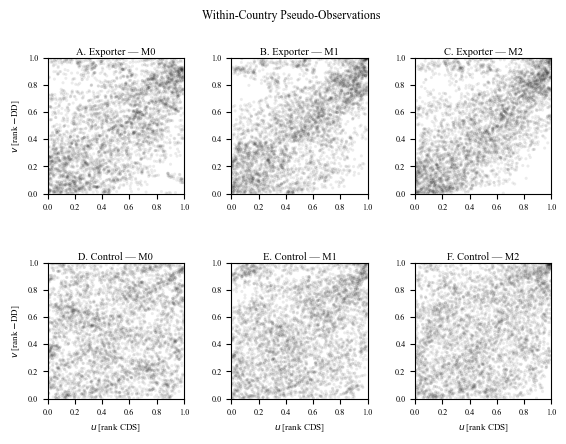

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(6.5, 4.5))
plt.subplots_adjust(hspace=0.45, wspace=0.35)

panel_labels = [['A','B','C'],['D','E','F']]

for i, (group_name, countries) in enumerate(groups.items()):
    for j, model in enumerate(models):
        ax = axes[i, j]
        u, v = within_country_uniforms(countries, model)

        ax.scatter(u, v, s=5, c='black', alpha=0.08, edgecolors='none')

        label = panel_labels[i][j]
        ax.set_title(f'{label}. {group_name} — {model}', fontsize=7.5, pad=2)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        ax.tick_params(axis='both', labelsize=6)
        if i == 1:
            ax.set_xlabel(r'$u$ [rank CDS]', fontsize=6.5)
        if j == 0:
            ax.set_ylabel(r'$v$ [rank $-$DD]', fontsize=6.5)

fig.suptitle('Within-Country Pseudo-Observations', fontsize=8.5, fontweight='normal')
plt.show()

In [39]:
from scipy.stats import norm, t as student_t
from scipy.optimize import minimize_scalar, minimize

def gaussian_loglik(u, v, rho):
    if abs(rho) >= 1:
        return -np.inf
    x = norm.ppf(np.clip(u, 1e-10, 1-1e-10))
    y = norm.ppf(np.clip(v, 1e-10, 1-1e-10))
    log_c = (-0.5 * np.log(1 - rho**2)
             - (rho**2 * (x**2 + y**2) - 2*rho*x*y) / (2*(1 - rho**2)))
    return np.sum(log_c)

def student_loglik(u, v, rho, nu):
    if abs(rho) >= 1 or nu <= 2:
        return -np.inf
    x = student_t.ppf(np.clip(u, 1e-10, 1-1e-10), df=nu)
    y = student_t.ppf(np.clip(v, 1e-10, 1-1e-10), df=nu)
    log_c = (np.log(1 - rho**2) * (-0.5)
             + student_t.logpdf((x - rho*y) / np.sqrt(1 - rho**2), df=nu+1)
             + student_t.logpdf((y - rho*x) / np.sqrt(1 - rho**2), df=nu+1)
             - student_t.logpdf(x, df=nu)
             - student_t.logpdf(y, df=nu))
    return np.sum(log_c)

def fit_gaussian(u, v):
    res  = minimize_scalar(lambda r: -gaussian_loglik(u, v, r),
                           bounds=(0.001, 0.999), method='bounded')
    rho  = res.x
    ll   = -res.fun
    aic  = -2*ll + 2
    return dict(family='Gaussian', theta=rho, nu=np.nan, loglik=ll, AIC=aic, tail_dep=0.0)

def fit_student(u, v):
    def neg_ll(params):
        rho, log_nu = params
        nu = np.exp(log_nu) + 2
        return -student_loglik(u, v, rho, nu)
    best_ll, best_params = np.inf, None
    for rho0 in [0.2, 0.5, 0.7]:
        for nu0 in [4, 10, 30]:
            res = minimize(neg_ll, x0=[rho0, np.log(nu0-2)],
                           method='Nelder-Mead',
                           options={'xatol':1e-5, 'fatol':1e-5, 'maxiter':2000})
            if res.fun < best_ll:
                best_ll, best_params = res.fun, res.x
    rho = best_params[0]
    nu  = np.exp(best_params[1]) + 2
    ll  = -best_ll
    aic = -2*ll + 4  # 2 parameters
    # tail dependence: 2*t_{nu+1}(-sqrt((nu+1)(1-rho)/(1+rho)))
    tail = 2 * student_t.cdf(-np.sqrt((nu+1)*(1-rho)/(1+rho)), df=nu+1)
    return dict(family='Student', theta=rho, nu=nu, loglik=ll, AIC=aic, tail_dep=tail)

def fit_all(u, v):
    g  = fit_gumbel(u, v)
    c  = fit_clayton(u, v)
    f  = fit_frank(u, v)
    ga = fit_gaussian(u, v)
    st = fit_student(u, v)
    all_fits = [g, c, f, ga, st]
    best_aic = min(d['AIC'] for d in all_fits)
    for d in all_fits:
        d['best'] = (d['AIC'] == best_aic)
    return all_fits

# ── Run ─────────────────────────────────────────────────────────────────────
results    = []
fits_store = {}

for group_name, countries in groups.items():
    for model in models:
        u, v     = within_country_uniforms(countries, model)
        all_fits = fit_all(u, v)
        best_fit = [d for d in all_fits if d['best']][0]
        fits_store[(group_name, model)] = (u, v, best_fit)
        for cop in all_fits:
            results.append({
                'Group':    group_name,
                'Model':    model,
                'Copula':   cop['family'],
                'theta':    cop['theta'],
                'nu':       cop.get('nu', np.nan),
                'loglik':   cop['loglik'],
                'AIC':      cop['AIC'],
                'tail_dep': cop['tail_dep'],
                'Best_AIC': cop['best'],
                'N':        len(u)
            })

res_df = pd.DataFrame(results)

# ── AIC table ───────────────────────────────────────────────────────────────
aic_pivot = res_df.pivot_table(index=['Group','Model'], columns='Copula', values='AIC').round(1)
aic_pivot['Best'] = aic_pivot.idxmin(axis=1)
print(aic_pivot[['Clayton','Frank','Gaussian','Gumbel','Student','Best']].to_string())

# ── Tail dependence for best-fit family ─────────────────────────────────────
best_df = res_df[res_df['Best_AIC']][['Group','Model','Copula','theta','nu','tail_dep']].copy()
print()
print(best_df.round(3).to_string(index=False))

Copula          Clayton      Frank  Gaussian  Gumbel  Student     Best
Group    Model                                                        
Control  M0       -20.5  5769359.2     -50.2  3523.3    -71.2  Student
         M1      -108.7  5769359.2    -187.1  2388.1   -258.8  Student
         M2      -186.5  5769359.2    -421.4  1450.9   -553.8  Student
Exporter M0      -710.7  5769359.2    -819.5   549.7  -1143.8  Student
         M1      -864.7  5769359.2   -1244.3  -683.3  -1666.3  Student
         M2     -1272.6  5769359.2   -1605.4 -1142.2  -2112.0  Student

   Group Model  Copula  theta    nu  tail_dep
Exporter    M0 Student  0.289 5.387     0.107
Exporter    M1 Student  0.356 5.872     0.115
Exporter    M2 Student  0.401 6.110     0.124
 Control    M0 Student  0.072 6.918     0.031
 Control    M1 Student  0.140 6.442     0.048
 Control    M2 Student  0.210 8.818     0.030


FileNotFoundError: [Errno 2] No such file or directory: '../output/figures/graph_copulas.pdf'

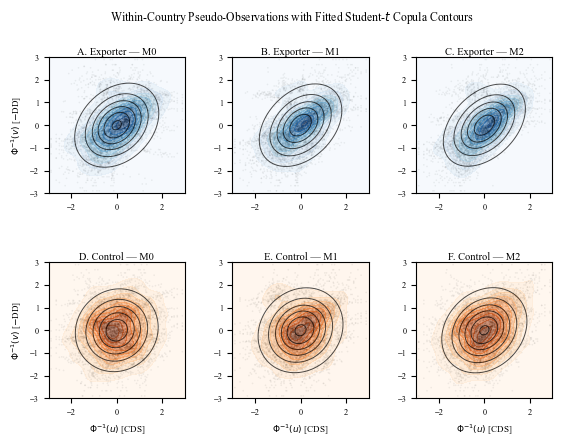

In [45]:
from scipy.stats import norm, t as student_t, multivariate_normal
from scipy.stats import gaussian_kde

cmaps = {'Exporter': 'Blues', 'Control': 'Oranges'}

fig, axes = plt.subplots(2, 3, figsize=(6.5, 4.5))
plt.subplots_adjust(hspace=0.45, wspace=0.35)
panel_labels = [['A','B','C'],['D','E','F']]

def bivariate_student_density(X, Y, rho, nu):
    pos = np.dstack((X, Y))
    cov = np.array([[1, rho], [rho, 1]])
    d = 2
    Z = (1 + (1/nu) * np.einsum('...i,ij,...j->...', pos, np.linalg.inv(cov), pos))
    return (1 / (np.pi * nu * np.sqrt(np.linalg.det(cov)))) * Z**(-(nu + d) / 2)

for i, (group_name, countries) in enumerate(groups.items()):
    for j, model in enumerate(models):
        ax = axes[i, j]
        u, v, best_fit = fits_store[(group_name, model)]

        x = norm.ppf(np.clip(u, 1e-4, 1-1e-4))
        y = norm.ppf(np.clip(v, 1e-4, 1-1e-4))

        # KDE filled contours of empirical data
        kde = gaussian_kde(np.vstack([x, y]), bw_method=0.3)
        g = np.linspace(-3, 3, 150)
        X, Y = np.meshgrid(g, g)
        Z_kde = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
        ax.scatter(x, y, s=1.5, c='black', alpha=0.12, edgecolors='none', zorder=0)
        ax.contourf(X, Y, Z_kde, levels=10, cmap=cmaps[group_name], alpha=0.5, zorder=1)

        # Theoretical bivariate Student-t ellipses on top
        rho, nu = best_fit['theta'], best_fit['nu']
        Z_t = bivariate_student_density(X, Y, rho, nu)
        ax.contour(X, Y, Z_t, levels=6, colors='black',
                   linewidths=0.7, alpha=0.7, zorder=2)

        label = panel_labels[i][j]
        ax.set_title(f'{label}. {group_name} — {model}', fontsize=7.5, pad=2)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect('equal')
        ax.tick_params(axis='both', labelsize=6)
        if i == 1:
            ax.set_xlabel(r'$\Phi^{-1}(u)$ [CDS]', fontsize=6.5)
        if j == 0:
            ax.set_ylabel(r'$\Phi^{-1}(v)$ [$-$DD]', fontsize=6.5)

fig.suptitle('Within-Country Pseudo-Observations with Fitted Student-$t$ Copula Contours',
             fontsize=8.5, fontweight='normal')
plt.savefig('../output/figures/graph_copulas.pdf', bbox_inches='tight', dpi=200)
plt.savefig('../output/figures/graph_copulas.png', bbox_inches='tight', dpi=200)
plt.show()

In [46]:
from scipy.optimize import minimize

def fit_student_fast(u, v):
    def neg_ll(params):
        rho, log_nu = params
        nu = np.exp(log_nu) + 2
        if abs(rho) >= 1 or nu <= 2:
            return np.inf
        x = student_t.ppf(np.clip(u, 1e-10, 1-1e-10), df=nu)
        y = student_t.ppf(np.clip(v, 1e-10, 1-1e-10), df=nu)
        log_c = (-0.5 * np.log(1 - rho**2)
                 + student_t.logpdf((x - rho*y) / np.sqrt(1 - rho**2), df=nu+1)
                 + student_t.logpdf((y - rho*x) / np.sqrt(1 - rho**2), df=nu+1)
                 - student_t.logpdf(x, df=nu)
                 - student_t.logpdf(y, df=nu))
        return -np.sum(log_c)
    best_ll, best_params = np.inf, None
    for rho0 in [0.2, 0.5]:
        for nu0 in [5, 10]:
            res = minimize(neg_ll, x0=[rho0, np.log(nu0-2)],
                           method='Nelder-Mead',
                           options={'xatol':1e-4, 'fatol':1e-4, 'maxiter':1000})
            if res.fun < best_ll:
                best_ll, best_params = res.fun, res.x
    rho = best_params[0]
    nu  = np.exp(best_params[1]) + 2
    tail = 2 * student_t.cdf(-np.sqrt((nu+1)*(1-rho)/(1+rho)), df=nu+1)
    return rho, nu, tail

def bootstrap_lambda(group_countries, model, n_boot=500, seed=42):
    np.random.seed(seed)
    dd_col = DD_COLS[model]
    
    # collect per-country arrays
    country_arrays = []
    for country in group_countries:
        mask = df[COUNTRY_COL] == country
        sub  = df.loc[mask, [CDS_COL, dd_col]].dropna()
        if len(sub) >= 10:
            country_arrays.append(sub.values)
    
    boot_lambdas = []
    for _ in range(n_boot):
        # resample observations within each country with replacement
        u_all, v_all = [], []
        for arr in country_arrays:
            idx = np.random.choice(len(arr), size=len(arr), replace=True)
            boot = arr[idx]
            n = len(boot)
            u = rankdata(boot[:, 0]) / (n + 1)
            v = rankdata(-boot[:, 1]) / (n + 1)
            u_all.append(u)
            v_all.append(v)
        u_pool = np.concatenate(u_all)
        v_pool = np.concatenate(v_all)
        try:
            _, _, lam = fit_student_fast(u_pool, v_pool)
            boot_lambdas.append(lam)
        except:
            continue
    
    return np.array(boot_lambdas)

# ── Run bootstrap for all 6 cells ──────────────────────────────────────────
N_BOOT = 500
boot_results = []

for group_name, countries in groups.items():
    for model in models:
        print(f'Bootstrapping {group_name} {model}...')
        lambdas = bootstrap_lambda(countries, model, n_boot=N_BOOT)
        boot_results.append({
            'Group':  group_name,
            'Model':  model,
            'lambda_mean': lambdas.mean(),
            'lambda_p025': np.percentile(lambdas, 2.5),
            'lambda_p975': np.percentile(lambdas, 97.5),
        })

boot_df = pd.DataFrame(boot_results)
print(boot_df.round(3).to_string(index=False))

Bootstrapping Exporter M0...
Bootstrapping Exporter M1...
Bootstrapping Exporter M2...
Bootstrapping Control M0...
Bootstrapping Control M1...
Bootstrapping Control M2...
   Group Model  lambda_mean  lambda_p025  lambda_p975
Exporter    M0        0.109        0.101        0.118
Exporter    M1        0.118        0.107        0.131
Exporter    M2        0.128        0.116        0.139
 Control    M0        0.033        0.029        0.038
 Control    M1        0.050        0.042        0.059
 Control    M2        0.034        0.021        0.047


In [47]:
all_countries = EXPORTERS + CONTROLS
country_results = []

for country in all_countries:
    group = 'Exporter' if country in EXPORTERS else 'Control'
    for model in models:
        dd_col = DD_COLS[model]
        mask = df[COUNTRY_COL] == country
        sub  = df.loc[mask, [CDS_COL, dd_col]].dropna()
        if len(sub) < 10:
            continue
        n = len(sub)
        u = rankdata(sub[CDS_COL].values) / (n + 1)
        v = rankdata(-sub[dd_col].values) / (n + 1)
        try:
            rho, nu, lam = fit_student_fast(u, v)
        except:
            rho, nu, lam = np.nan, np.nan, np.nan
        country_results.append({
            'Country': country,
            'Group':   group,
            'Model':   model,
            'rho':     round(rho, 3),
            'nu':      round(nu, 2),
            'lambda':  round(lam, 3)
        })

country_df = pd.DataFrame(country_results)
pivot_rho = country_df.pivot_table(index=['Group','Country'], columns='Model', values='rho')[['M0','M1','M2']]
pivot_nu  = country_df.pivot_table(index=['Group','Country'], columns='Model', values='nu')[['M0','M1','M2']]
pivot_lam = country_df.pivot_table(index=['Group','Country'], columns='Model', values='lambda')[['M0','M1','M2']]

print('=== rho ===')
print(pivot_rho.round(3).to_string())
print('\n=== nu ===')
print(pivot_nu.round(2).to_string())
print('\n=== lambda ===')
print(pivot_lam.round(3).to_string())

=== rho ===
Model                        M0     M1     M2
Group    Country                             
Control  Chile            0.250  0.372  0.465
         China           -0.119 -0.096  0.003
         Indonesia        0.171  0.270  0.427
         Philippines     -0.317 -0.234 -0.164
         South Africa     0.117  0.184  0.187
         South Korea      0.097  0.070  0.085
         Thailand        -0.094  0.060  0.208
         Turkey           0.588  0.628  0.653
Exporter Brazil           0.348  0.432  0.414
         Colombia         0.348  0.343  0.378
         Egypt            0.280  0.279  0.311
         Malaysia         0.317  0.220  0.482
         Mexico           0.267  0.358  0.354
         Qatar            0.440  0.472  0.521
         Saudi Arabia     0.528  0.582  0.571
         UAE (Abu Dhabi) -0.078  0.249  0.268

=== nu ===
Model                               M0            M1            M2
Group    Country                                                  
Control  Chile